### Stations

In [2]:
import requests
import pandas as pd
import time

In [59]:
url = "https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/stations"
params = {"size": 5000, "code_bss" :"09937X0135/P23B,09934X0087/P18B,10193X0151/P29B,09938X0164/P12B,10192X0095/P21B,10916X0061/F1N4,10906X0039/C2-1"}
#params = {"size": 5000, "code_departement" :"13"}
headers = {"accept": "application/json"}

response = requests.get(url, params=params, headers=headers)
response.raise_for_status() 

data = response.json()
df_station = pd.DataFrame(data["data"])
df_station = df_station.rename(columns={"code_bss": "code_station", "y": "longitude", "x": "latitude"})

print(data.get("count"), "résultats au total")
display(df_station.describe())
display(df_station.head())

display(df_station["nom_commune"].value_counts())

# df_station.to_csv("/home/ronanguilloueee/NappeCast/data/external/station_data_full.csv")

7 résultats au total


,latitude,longitude,nb_mesures_piezo,profondeur_investigation
count,7.000000,7.000000,7.000000,7.000000
mean,4.325386,43.333016,8346.857143,32.930000
std,1.011319,0.426238,476.736975,48.319795
min,2.685378,42.685696,7900.000000,9.000000
25%,3.918245,43.138650,8038.500000,12.505000
50%,4.871875,43.550764,8186.000000,15.000000
75%,4.929412,43.584231,8545.500000,19.750000
max,5.025133,43.648887,9174.000000,142.000000


,code_station,urn_bss,date_debut_mesure,date_fin_mesure,code_commune_insee,nom_commune,latitude,longitude,codes_bdlisa,urns_bdlisa,...,altitude_station,nb_mesures_piezo,code_departement,nom_departement,libelle_pe,profondeur_investigation,codes_masse_eau_edl,noms_masse_eau_edl,urns_masse_eau_edl,date_maj
0,10906X0039/C2-1,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-14,2026-07-13,66108,Millas,2.685378,42.685696,[718BP02],[http://reseau.eaufrance.fr/geotraitements/bdl...,...,107.16,8840,66,Pyrénées-Orientales,MILLAS C2-1,9.0,[DG351],[Alluvions quaternaires du Roussillon],[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,Fri Jan 24 16:44:49 CET 2020
1,10916X0061/F1N4,http://services.ades.eaufrance.fr/pointeau/109...,1980-04-01,2026-07-14,66182,Sainte-Marie-la-Mer,3.025092,42.737394,[671AA00],[http://reseau.eaufrance.fr/geotraitements/bdl...,...,2.48,9174,66,Pyrénées-Orientales,SAINTE-MARIE N4,142.0,[DG243],[Multicouche pliocène du Roussillon],[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,Fri Feb 28 06:02:36 CET 2025
2,10192X0095/P21B,http://services.ades.eaufrance.fr/pointeau/101...,2002-01-23,2026-07-15,13004,Arles,4.811397,43.539905,[561AF00],[http://reseau.eaufrance.fr/geotraitements/bdl...,...,4.0,7900,13,Bouches-du-Rhône,Arles - Négreiron,12.0,[DG104],[Cailloutis de la Crau],[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,Thu Jul 31 21:19:00 CEST 2025
3,09938X0164/P12B,http://services.ades.eaufrance.fr/pointeau/099...,2003-01-30,2026-07-15,13063,Miramas,5.025133,43.590416,[561AE00],[http://reseau.eaufrance.fr/geotraitements/bdl...,...,60.0,8186,13,Bouches-du-Rhône,Miramas - les Cabasses,24.0,[DG513],[Formations variées du bassin versant de la To...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,Fri Jun 28 07:31:38 CEST 2024
4,09937X0135/P23B,http://services.ades.eaufrance.fr/pointeau/099...,2003-06-02,2026-07-15,13097,Saint-Martin-de-Crau,4.871875,43.578046,[561AF00],[http://reseau.eaufrance.fr/geotraitements/bdl...,...,24.0,8114,13,Bouches-du-Rhône,Saint-Martin-de-Crau - le Petit Carton,15.0,[DG104],[Cailloutis de la Crau],[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,Fri Jun 28 07:31:38 CEST 2024


nom_commune
Saint-Martin-de-Crau    2
Millas                  1
Sainte-Marie-la-Mer     1
Arles                   1
Miramas                 1
Istres                  1
Name: count, dtype: int64

### Piezometre

In [64]:
url = "https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques"
headers = {"accept": "application/json"}

def fetch_next_page(first_url: str,
               code_station: str) -> pd.DataFrame:
    data_page = []
    next_url = first_url
    params = {
        "code_bss": code_station,
        "page": 1,
        "size": 5000
    }

    while next_url:
        try:
            r = requests.get(next_url, params=params, headers=headers, timeout=(5, 30))
            r.raise_for_status()
            print (r.url)

        except requests.exceptions.Timeout:
            print("Timeout, nouvelle tentative...")
            time.sleep(2)
            continue 

        data = r.json()
        data_page.extend(data["data"])
        next_url = data.get("next")
        params = None

        time.sleep(1)
        
    df = pd.DataFrame(data_page)
    return df

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
 
def plot_station(df: pd.DataFrame) :
    # Chargement des données
    df["date_mesure"] = pd.to_datetime(df["date_mesure"])
    df = df.sort_values("date_mesure")
    # Plot : une courbe par piézomètre (code_bss)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for code_bss, station in df.groupby("code_bss"):
        ax.plot(station["date_mesure"], station["niveau_nappe_eau"], marker="o", markersize=3, linewidth=1, label=code_bss)
    
    ax.set_title("Variation du niveau de nappe par piézomètre")
    ax.set_xlabel("Date")
    ax.set_ylabel("Niveau de nappe (m)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Piézomètre", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2027-01-01'))

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig("niveau_nappe_multi.png", dpi=150)
    plt.show()

In [65]:
df_p= []
for i, (code_station, lat, lon) in enumerate(zip(df_station["code_station"], df_station["latitude"], df_station["longitude"])):
    print (f"----- Station: {code_station}, latitude:{lat}-longitude:{lon}")
    df_cache = fetch_next_page(url, code_station)
    df_p.append(df_cache)

piezometre_df = pd.concat(df_p, ignore_index=True)
file = f"/home/ronanguilloueee/NappeCast/data/external/piezometre_data_selection.csv"
piezometre_df.to_csv(file)

----- Station: 10906X0039/C2-1, latitude:2.685378283-longitude:42.685696389
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10906X0039%2FC2-1&page=1&size=5000
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10906X0039/C2-1&page=2&size=5000
----- Station: 10916X0061/F1N4, latitude:3.025092487-longitude:42.737394474
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10916X0061%2FF1N4&page=1&size=5000
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10916X0061/F1N4&page=2&size=5000
----- Station: 10192X0095/P21B, latitude:4.811397298-longitude:43.539904887
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10192X0095%2FP21B&page=1&size=5000
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10192X0095/P21B&page=2&size=5000
----- Station: 09938X0164/P12B, latitude:5.025132831-longitude:43.590415962
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=09

----- Station: 10906X0039/C2-1, latitude:2.685378283-longitude:42.685696389


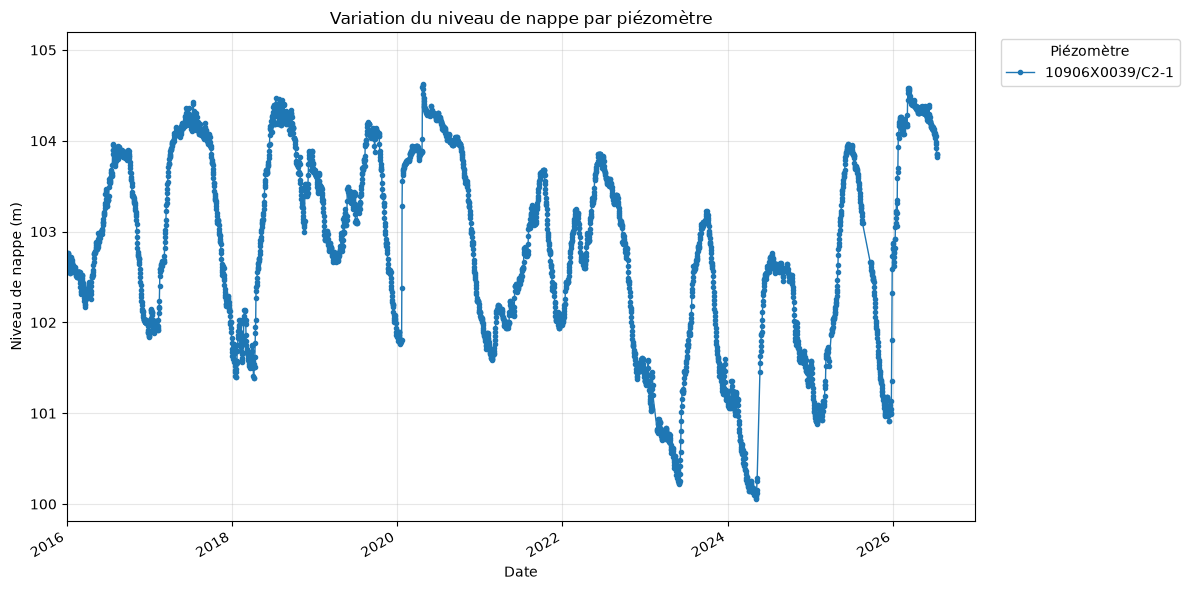

----- Station: 10916X0061/F1N4, latitude:3.025092487-longitude:42.737394474


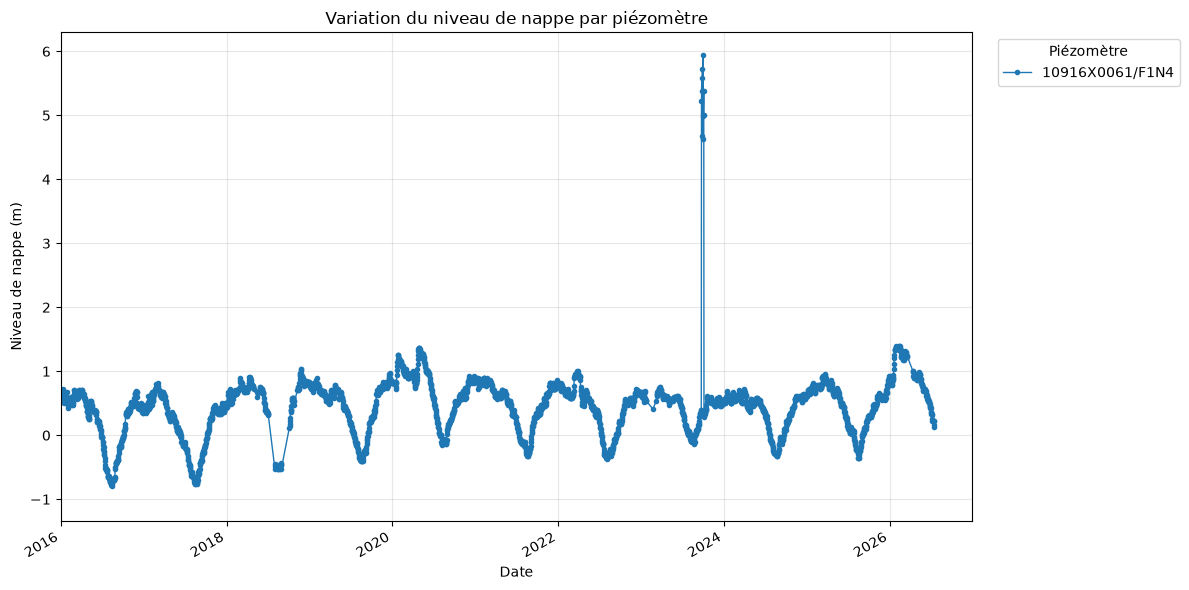

----- Station: 10192X0095/P21B, latitude:4.811397298-longitude:43.539904887


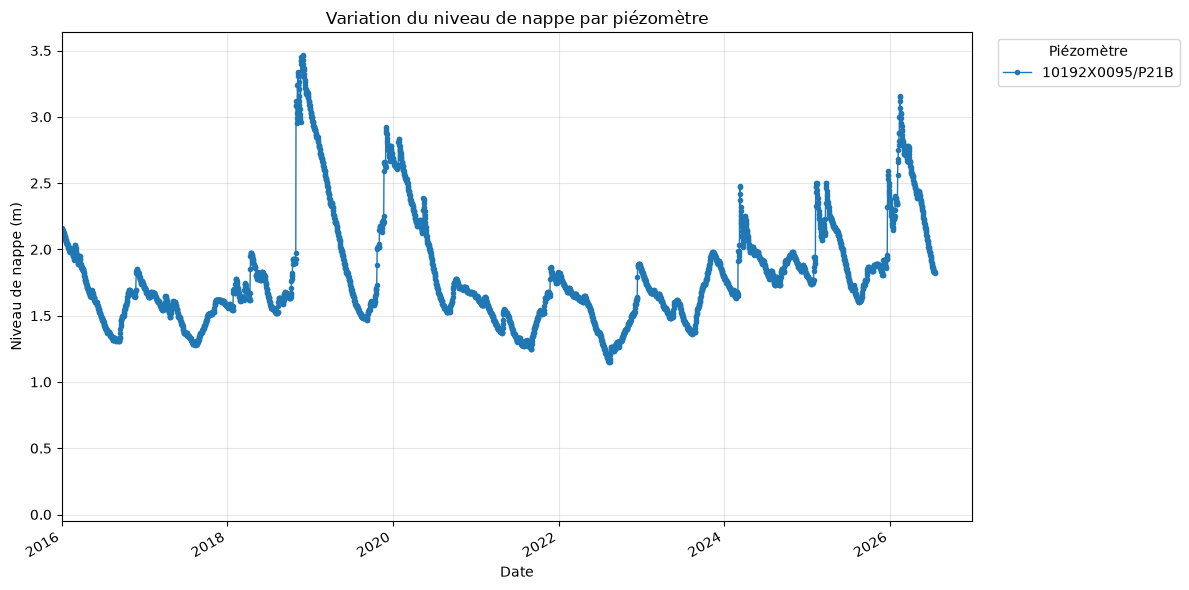

----- Station: 09938X0164/P12B, latitude:5.025132831-longitude:43.590415962


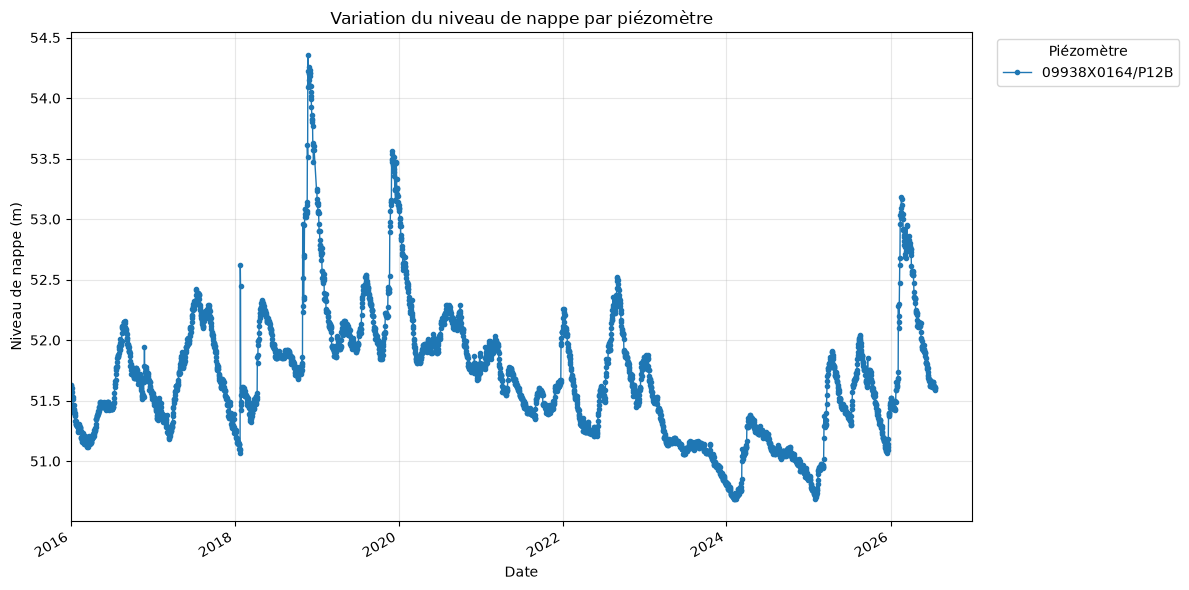

----- Station: 09937X0135/P23B, latitude:4.871874989-longitude:43.578046374


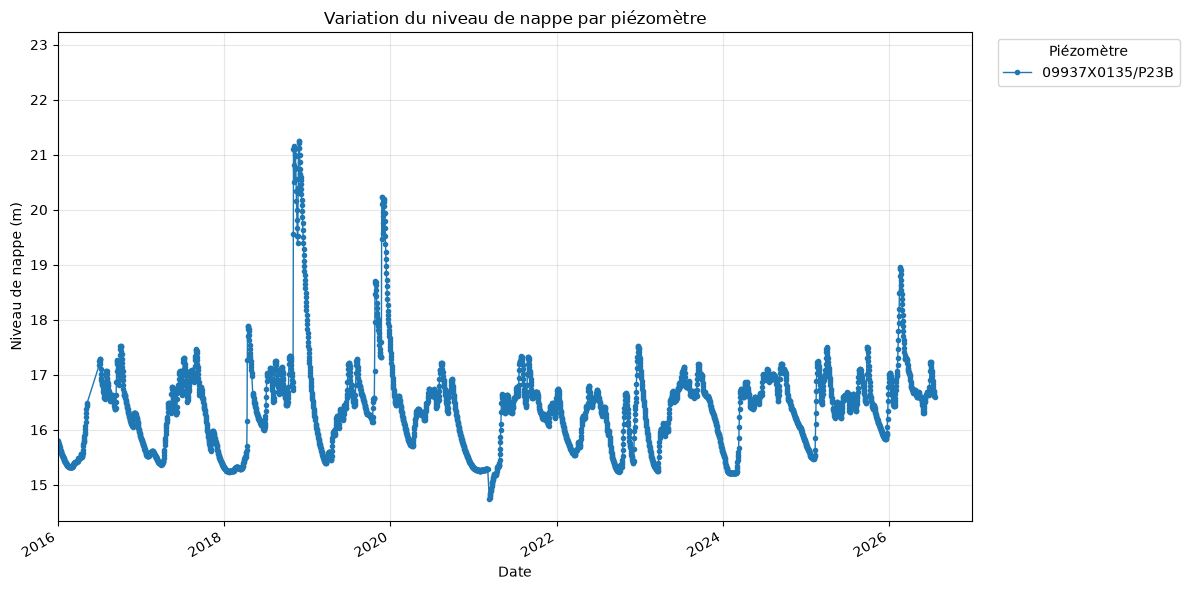

----- Station: 09934X0087/P18B, latitude:4.961161123-longitude:43.648887185


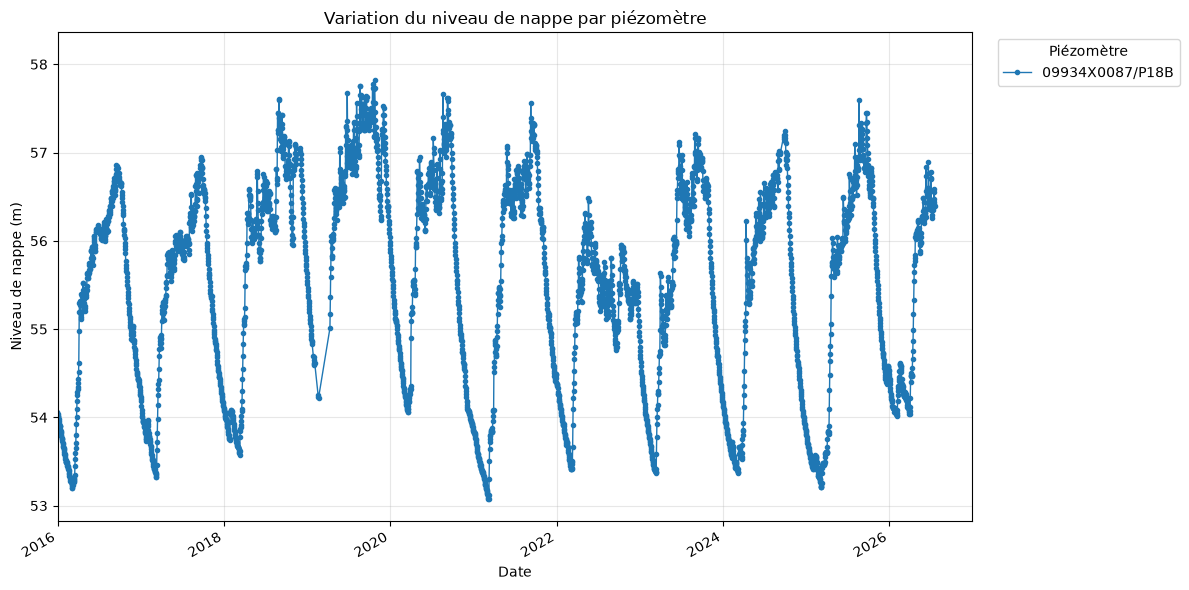

----- Station: 10193X0151/P29B, latitude:4.897662374-longitude:43.55076448


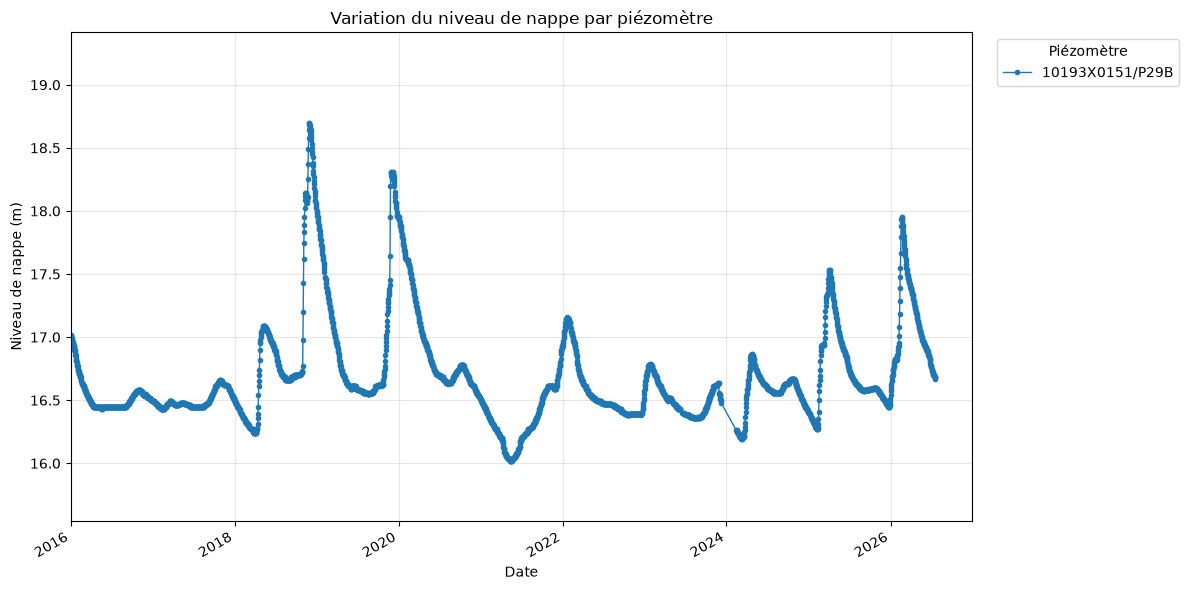

In [69]:
for i, (code_station, lat, lon) in enumerate(zip(df_station["code_station"], df_station["latitude"], df_station["longitude"])):
    print (f"----- Station: {code_station}, latitude:{lat}-longitude:{lon}")

    mask = (piezometre_df["code_bss"]==code_station)
    df_choice = piezometre_df[mask]
    
    plot_station (df_choice)



